# **Tesla EA Deliveries and Production Data ML Pipeline**

In [1]:
!pip install statsmodels

In [2]:
from statsmodels.tsa.arima.model import ARIMA

## **Pre-Processing**

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('/content/data.csv')

print(f'Shape: {df.shape}')
print(f'Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.2f} MB')
df.head(10)
print('=== DATA TYPES ===')
print(df.dtypes)
print('\n=== MISSING VALUES ===')
print(df.isnull().sum())
print('\n=== STATISTICAL SUMMARY ===')
df.describe()


Shape: (2640, 12)
Memory usage: 0.67 MB
=== DATA TYPES ===
Year                      int64
Month                     int64
Region                   object
Model                    object
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type              object
Charging_Stations         int64
dtype: object

=== MISSING VALUES ===
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

=== STATISTICAL SUMMARY ===


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [4]:
df['Region'].nunique()

4

In [5]:
df['Model'].nunique()

5

In [6]:
df['Source_Type'].nunique()

3

In [7]:
df[['Region','Model','Source_Type']].drop_duplicates().shape

(60, 3)

We can observe that data is already pre processed as there is no missing value or any insight outlier.

## **Exploratory Data Analysis (EDA)**

In [8]:
print(df['Region'].value_counts())
print(df['Model'].value_counts())
print(df['Source_Type'].value_counts())

Region
Europe           660
Asia             660
North America    660
Middle East      660
Name: count, dtype: int64
Model
Model S       528
Model X       528
Model 3       528
Model Y       528
Cybertruck    528
Name: count, dtype: int64
Source_Type
Interpolated (Month)    884
Official (Quarter)      884
Estimated (Region)      872
Name: count, dtype: int64


<Axes: xlabel='Estimated_Deliveries', ylabel='Count'>

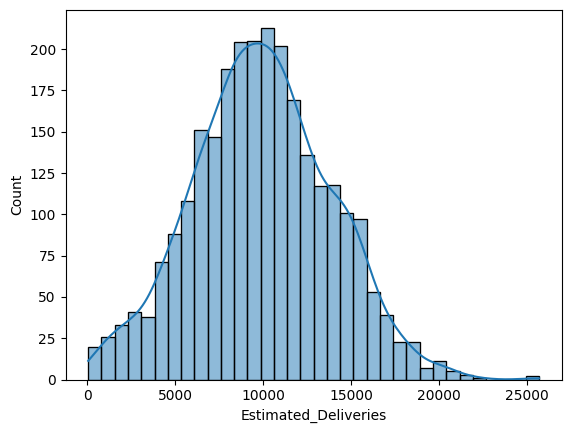

In [9]:
sns.histplot(df['Estimated_Deliveries'], kde=True)

np.float64(0.08825089558953238)

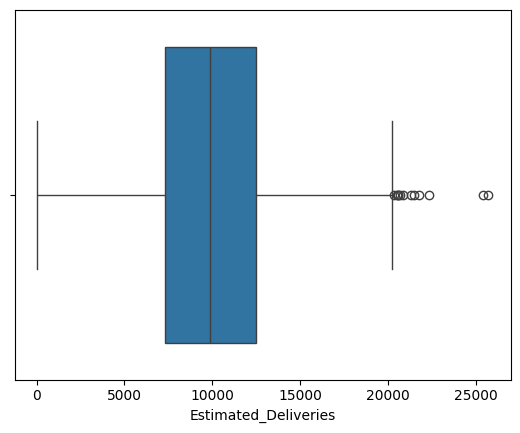

In [10]:
sns.boxplot(x=df['Estimated_Deliveries'])
df['Estimated_Deliveries'].skew()

<Axes: xlabel='Year', ylabel='Estimated_Deliveries'>

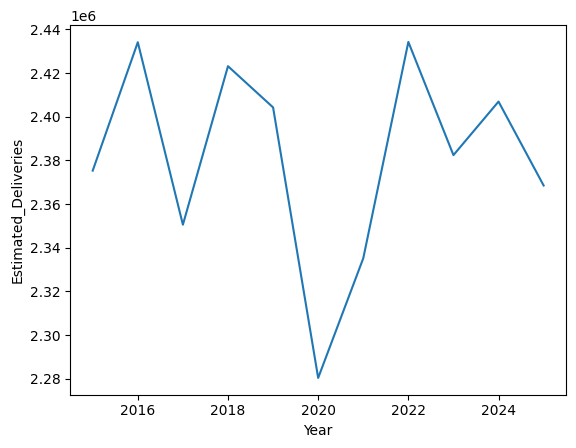

In [11]:
monthly_deliveries = (
    df.groupby(['Year'])['Estimated_Deliveries']
      .sum()
      .reset_index()
)
sns.lineplot(
    data=monthly_deliveries,
    x='Year',
    y='Estimated_Deliveries'
)

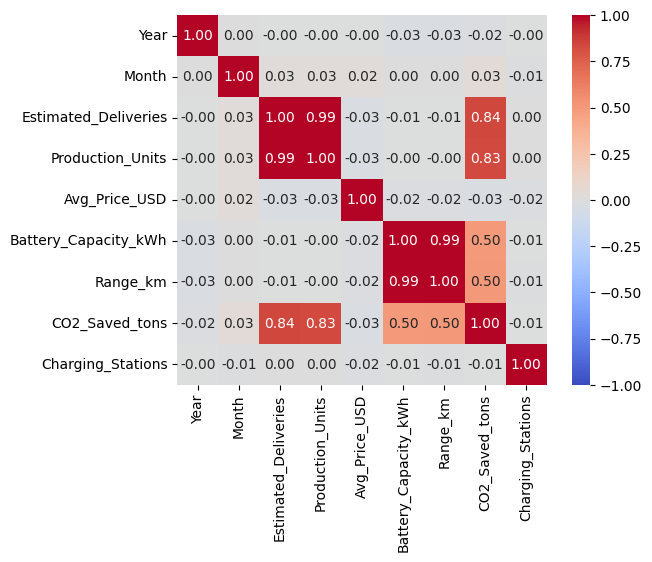

In [12]:
numeric_df = df.select_dtypes(include='number')
corr = numeric_df.corr()
#Estimated_Deliveries vs Production_Units
c1 = corr.loc[['Estimated_Deliveries'], ['Production_Units']]
sns.heatmap(corr, cmap = "coolwarm", annot = True, vmax=1, vmin=-1, square=True, fmt=".2f")
plt.show()

In [13]:
corr_target = (
    df.corr(numeric_only=True)
      ['Estimated_Deliveries']
      .sort_values(ascending=False)
)

print(corr_target)

Estimated_Deliveries    1.000000
Production_Units        0.994234
CO2_Saved_tons          0.836814
Month                   0.030877
Charging_Stations       0.000753
Year                   -0.002863
Range_km               -0.006606
Battery_Capacity_kWh   -0.007765
Avg_Price_USD          -0.027546
Name: Estimated_Deliveries, dtype: float64


By observe these plot and maps we can tell that the database is has synthetic as the **distribution of data is uniform**. The target variable, Estimated Deliveries, follows an approximately normal distribution, making it suitable for regression modeling. Correlation analysis showed a very **strong positive relationship** between Production Units and Estimated Deliveries (0.994), identifying production volume as the most influential predictor. CO₂ Saved Tons also exhibited a strong correlation with deliveries (0.837), while Battery Capacity and Range were found to be highly correlated (0.99), indicating feature redundancy.

## **Feature Engineering and Feature Selection**

In [14]:
df["Quarter"] = (
    (df["Month"]-1)//3
)+1

In [15]:
df = df.sort_values(
    ["Region","Model","Year","Month"]
)

df["Lag_1"] = (
    df.groupby(
        ["Region","Model"]
    )["Estimated_Deliveries"]
     .shift(1)
)

df["Lag_3"] = (
    df.groupby(
        ["Region","Model"]
    )["Estimated_Deliveries"]
     .shift(3)
)

In [16]:
df["Rolling_3"] = (
    df.groupby(
        ["Region","Model"]
    )["Estimated_Deliveries"]
    .transform(
        lambda x:
        x.rolling(3).mean()
    )
)

In [17]:
df = df.dropna()
df.drop(
    columns=['Battery_Capacity_kWh'],
    inplace=True
)

Here, we added lag features and rolling mean plus Quarter as feature indicating the phase of the year.

### **Encoding**

In [18]:
df = pd.get_dummies(
    df,
    columns=[
        'Region',
        'Model',
        'Source_Type'
    ],
    drop_first=True
)

In [19]:
y = df['Estimated_Deliveries']
X = df.drop(
    columns=[
        'Estimated_Deliveries'
    ]
)

In [20]:
split = int(len(df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [21]:
X_train.shape, X_test.shape

((2064, 20), (516, 20))

## **Regression Modeling**

In [22]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(
    X_train,
    y_train
)

LinearRegression()

In [23]:
pred_lr = lr.predict(X_test)

In [24]:

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score
)

print("MAE:", mean_absolute_error(y_test, pred_lr))

print("RMSE:", root_mean_squared_error(y_test, pred_lr))

print("R2:", r2_score(y_test, pred_lr))

MAE: 304.15641925242886
RMSE: 374.88381218421506
R2: 0.9907409321401739


In [25]:
from sklearn.ensemble import RandomForestRegressor

rfr = RandomForestRegressor()
rfr.fit(X_train, y_train)
pred_rfr = rfr.predict(X_test)

In [26]:
print("MAE:", mean_absolute_error(y_test, pred_rfr))

print("RMSE:", root_mean_squared_error(y_test, pred_rfr))

print("R2:", r2_score(y_test, pred_rfr))

MAE: 321.5642829457364
RMSE: 438.92133629925183
R2: 0.9873074969238148


The regression modeling phase involved training and evaluating **Linear Regression** and **Random Forest Regressor** models to predict Estimated Deliveries. Model performance was assessed using MAE, RMSE, and R² metrics, with Linear Regression achieving the best overall results due to the strong linear relationships present in the dataset.

## **Cross Validation**

In [27]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import cross_val_score

In [28]:
tscv = TimeSeriesSplit(n_splits=5)

scores_lr = cross_val_score(
    LinearRegression(),
    X,
    y,
    cv=tscv,
    scoring='r2'
)

print(scores_lr)
print(scores_lr.mean())

[0.98924989 0.99071514 0.98917736 0.99097178 0.99057588]
0.9901380100184433


In [29]:
scores_rf = cross_val_score(
    RandomForestRegressor(random_state=42),
    X,
    y,
    cv=tscv,
    scoring='r2'
)

print(scores_rf)
print(scores_rf.mean())

[0.98590147 0.98788429 0.98669728 0.98499321 0.98911562]
0.9869183725139002


To ensure the reliability and generalization capability of the models, **TimeSeriesSplit cross-validation** was performed.

## **Hyperparameter tunning**

In [30]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_grid,
    n_iter=20,
    cv=tscv,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

rf_search.fit(X_train, y_train)

RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
                   estimator=RandomForestRegressor(random_state=42), n_iter=20,
                   n_jobs=-1,
                   param_distributions={'max_depth': [5, 10, 15, 20, None],
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42, scoring='r2')

In [31]:
print("Best Parameters:")
print(rf_search.best_params_)

print("\nBest CV Score:")
print(rf_search.best_score_)

Best Parameters:
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 20}

Best CV Score:
0.9871164503719715


In [32]:
best_rf = rf_search.best_estimator_

Various parameter combinations were evaluated to optimize model performance, although the tuned model did not outperform the baseline Linear Regression model.

# **Final Evaluation**

In [33]:
pred_rf_tuned = best_rf.predict(X_test)

In [34]:
print("MAE:", mean_absolute_error(y_test, pred_rf_tuned))

print("RMSE:", root_mean_squared_error(y_test, pred_rf_tuned))

print("R2:", r2_score(y_test, pred_rf_tuned))

MAE: 321.56206967703906
RMSE: 440.7500985413262
R2: 0.9872015101609449


Here, we tunned the RF model as LR doesn't have many parameters to tune. Hyperparameter tunning was performed using RandomizedSearchCV with TimeSeriesSplit cross-validation. But it **did not outperform or gave any positive result**. We can conculde that as previously mentioned **data is highly linear** as we saw that base LR is best performing eving after RF tunning. Hence database exhibits **linear relationship** thus using Linear Regression Model for **Regression Modeling**

## **Time Series Forcasting**

In [35]:
df['Date'] = pd.to_datetime(
    df['Year'].astype(str)
    + '-'
    + df['Month'].astype(str)
)

monthly_deliveries = (
    df.groupby('Date')['Estimated_Deliveries']
      .sum()
      .reset_index()
)

In [36]:
print(monthly_deliveries.head())
print(monthly_deliveries.shape)

        Date  Estimated_Deliveries
0 2015-04-01                225623
1 2015-05-01                184264
2 2015-06-01                198787
3 2015-07-01                177759
4 2015-08-01                214223
(129, 2)


In [37]:

# plt.figure(figsize=(12,5))
# plt.plot(
#     monthly_deliveries['Date'],
#     monthly_deliveries['Estimated_Deliveries']
# )
# plt.title('Monthly Tesla Deliveries')
# plt.show()

In [38]:
train = monthly_deliveries[:-12]
test = monthly_deliveries[-12:]

In [39]:
print(train.shape)
print(test.shape)

(117, 2)
(12, 2)


In [40]:
model = ARIMA(
    train['Estimated_Deliveries'],
    order=(1,0,1)
)

model_fit = model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [41]:
forecast = model_fit.forecast(
    steps=len(test)
)

In [42]:
mae = mean_absolute_error(
    test['Estimated_Deliveries'],
    forecast
)

rmse = root_mean_squared_error(
    test['Estimated_Deliveries'],
    forecast
)

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 10489.412957131324
RMSE: 12979.263792025506


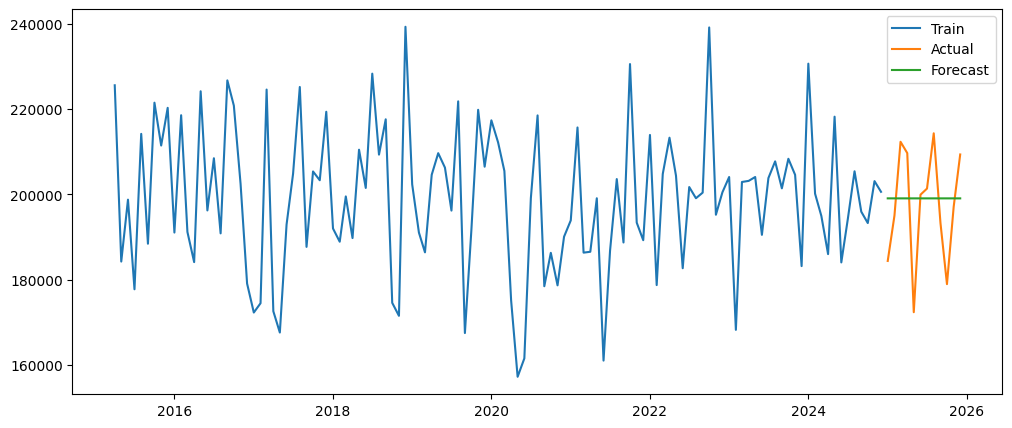

In [43]:


plt.figure(figsize=(12,5))

plt.plot(
    train['Date'],
    train['Estimated_Deliveries'],
    label='Train'
)

plt.plot(
    test['Date'],
    test['Estimated_Deliveries'],
    label='Actual'
)

plt.plot(
    test['Date'],
    forecast,
    label='Forecast'
)

plt.legend()
plt.show()


ARIMA(1,0,1) was used for forecasting monthly Tesla deliveries. The forecast remained relatively stable around the historical mean, indicating the absence of strong trends or seasonal patterns in the dataset. The model achieved an **MAE of 10,489** and an **RMSE of 12,979**, corresponding to approximately **6.5% error relative to average monthly deliveries.


### **Conclusion**
The objective of designing and implementing an **end-to-end machine learning pipeline** was successfully achieved using the **Tesla EV dataset**. The pipeline included **data exploration (EDA), feature engineering, feature selection, regression modeling, cross-validation, hyperparameter tuning, and time-series forecasting**. Through comparative analysis, **Linear Regression** emerged as the **best-performing model** with an **R² score of 0.9907**, demonstrating the **strong linear relationships** present in the dataset. Additionally, **ARIMA-based forecasting** was used to predict **future delivery trends**, providing insights into **temporal patterns** in the data. Overall, the project demonstrated a complete machine learning workflow and highlighted the importance of data-driven decision-making in predictive analytics.